<a href="https://colab.research.google.com/github/ssanish686/AI-Learning/blob/main/CNN_Image_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [3]:
from google.colab import files
from PIL import Image

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
x_train.shape

(60000, 28, 28)

In [42]:
y_train.shape

(60000,)

In [6]:
x_test.shape

(10000, 28, 28)

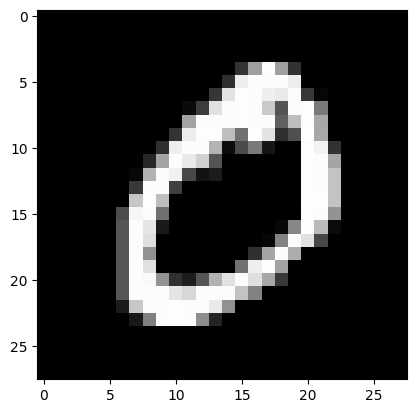

In [12]:
plt.imshow(x_train[1], cmap='gray')

In [14]:
sample_pixel=x_train[800]
print(sample_pixel[:,:])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6 143 254 254 254 254
  255 217  54   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  26 181 254 254 254 254 254
  254 254 165   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  28 215 254 237 101  1

In [15]:
x_train_norm = x_train.astype("float32")/255.0
x_test_norm = x_test.astype("float32")/255.0

In [17]:
normalized_pixel = x_train_norm[800]
print(normalized_pixel[:,:])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [24]:
sample_image=x_train_norm[0:1]

In [19]:
sample_conv=layers.Conv2D(filters=4, kernel_size=(3,3), activation='relu')

In [20]:
sample_pool=layers.MaxPool2D(pool_size=(2,2))

In [21]:
sample_image=np.expand_dims(sample_image, axis=-1)

In [22]:
conv_output=sample_conv(sample_image)

In [23]:
pool_output=sample_pool(conv_output)

In [27]:
pool_output.shape

TensorShape([1, 13, 13, 4])

In [31]:
flatten_output=layers.Flatten()(pool_output)

In [32]:
flatten_output.shape

TensorShape([1, 676])

In [37]:
from os import name
model = models.Sequential([
    layers.Input(shape=(28,28,1),name="input_layer"),
    layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', name="conv_layer_1"),
    layers.MaxPool2D(pool_size=(2,2), name="pooling_layer_1"),
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', name="conv_layer_2"),
    layers.MaxPool2D(pool_size=(2,2), name="pooling_layer_2"),
    layers.Flatten(name="flatten_layer"),
    layers.Dense(units=64, activation='relu', name="hidden_layer_1"),
    layers.Dense(units=32, activation='relu', name="hidden_layer_2"),
    layers.Dense(units=10, activation='softmax', name="output_layer")
])

In [39]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [41]:
model.fit(x_train_norm, y_train, epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9269 - loss: 0.2291
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9786 - loss: 0.0687
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9843 - loss: 0.0504
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9880 - loss: 0.0393
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9895 - loss: 0.0332
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9912 - loss: 0.0265
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9931 - loss: 0.0213
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9941 - loss: 0.0187
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9950 - loss: 0.0147
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9959 - loss: 0.0123
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9962 - loss: 0.0114
Epoch 12

In [43]:
test_loss, test_accuracy=model.evaluate(x_test_norm, y_test)
print("test accuracy", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9890 - loss: 0.0573
test accuracy 0.9890000224113464


In [44]:
upload=files.upload()

Saving 3_images.jpg to 3_images.jpg


In [45]:
image_path=list(upload.keys())[0]

In [46]:
img=Image.open(image_path)

In [47]:
img=img.convert("L")

In [49]:
img=img.resize((28,28))

In [50]:
image_array=np.array(img)

In [56]:
print(image_array)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.00392157 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.00392157 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157 0.00392157 0.00784314
  0.00784314 0.00784314 0.00784314 0.00784314 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157]
 [0.         0.         0.         0.         0.         0.
  0.         0.        

In [52]:
image_array= image_array/255.0

In [62]:
print(image_array)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.00392157 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.00392157 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157 0.00392157 0.00784314
  0.00784314 0.00784314 0.00784314 0.00784314 0.00392157 0.00392157
  0.00392157 0.00392157 0.00392157 0.00392157]
 [0.         0.         0.         0.         0.         0.
  0.         0.        

In [57]:
input_image=image_array.reshape(1,28,28,1)

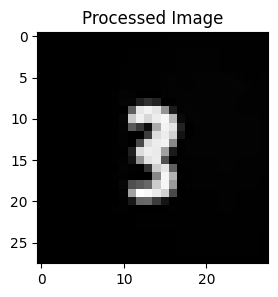

In [61]:
plt.figure(figsize=(5,3))
plt.imshow(input_image.squeeze(),cmap='gray')
plt.title("Processed Image")
plt.show()

In [58]:
prediction=model.predict(input_image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [60]:
predictionDigit = np.argmax(prediction)
print("prediction = ",predictionDigit)

prediction =  3
